# Step 3, Create Word Cloud for each Decade

In [119]:
from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer, SnowballStemmer
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import pandas as pd
import string
import numpy as np

## Load Data

In [120]:

other_word = [
    "area", "the", "be", "to", "of", "and", "a", "in", "that", "have", "I", "it", "for", "not", "on", "with", "he", "as", 
    "you", "do", "at", "this", "but", "his", "by", "from", "they", "we", "say", "her", "she", "or", "an", "will", 
    "my", "one", "all", "would", "there", "their", "what", "so", "up", "out", "if", "about", "who", "get", "which", 
    "go", "me", "when", "make", "can", "like", "time", "no", "just", "him", "know", "take", "people", "into", "year", 
    "your", "good", "some", "could", "them", "see", "other", "than", "then", "now", "look", "only", "come", "its", 
    "over", "think", "also", "back", "after", "use", "two", "how", "our", "work", "first", "well", "way", "even", 
    "new", "want", "because", "any", "these", "give", "day", "most", "us", "is", "are", "was", "were", "been", 
    "being", "had", "has", "do", "does", "did", "am", "are", "is", "was", "were", "be", "being", "been", "have", 
    "has", "had", "do", "does", "did", "can", "could", "will", "would", "shall", "should", "may", "might", "must", 
    "ought", "there", "here", "where", "when", "why", "how", "what", "which", "who", "whom", "whose", "if", "though", 
    "since", "unless", "until", "while", "because", "so", "so that", "in order that", "that", "lest", "lest", "rather", 
    "whether", "who", "whoever", "whomever", "whichever", "whatever", "he", "him", "his", "she", "her", "hers", "it", 
    "its", "they", "them", "their", "theirs", "we", "us", "our", "ours", "you", "your", "yours", "ye", "thee", "thou", 
    "thine", "my", "mine", "our", "ours", "your", "yours", "his", "her", "its", "their", "theirs", "n't", "d", "ll", 
    "m", "o", "re", "s", "t", "ve", "y", "ain", "aren", "couldn", "didn", "doesn", "hadn", "hasn", "haven", "isn", 
    "ma", "mightn", "mustn", "needn", "shan", "shouldn", "wasn", "weren", "won", "wouldn", "also", "am", "am", "aren",
    "aren", "be", "be", "because", "been", "been", "being", "being", "both", "but", "by", "can", "couldn", "couldn", 
    "did", "didn", "didn", "do", "does", "doesn", "doesn", "doing", "don", "don", "down", "during", "each", "few", 
    "for", "from", "further", "had", "hadn", "hadn", "has", "hasn", "hasn", "have", "haven", "haven", "having", 
    "he", "her", "here", "hers", "herself", "him", "himself", "his", "how", "i", "if", "in", "into", "is", "isn", 
    "isn", "it", "it", "itself", "just", "ll", "m", "ma", "me", "mightn", "mightn", "more", "most", "mustn", 
    "mustn", "my", "myself", "needn", "needn", "no", "nor", "not", "now", "o", "of", "off", "on", "once", "only", 
    "or", "other", "our", "ours", "ourselves", "out", "over", "own", "re", "s", "same", "shan", "shan", "she", 
    "she", "should", "should", "shouldn", "shouldn", "so", "some", "such", "t", "than", "that", "that", "the", 
    "their", "their", "theirs", "them", "themselves", "then", "there", "these", "they", "this", "those", "through", 
    "to", "too", "under", "until", "up", "ve", "very", "was", "wasn", "wasn", "we", "were", "were", "weren", 
    "weren", "what", "what", "when", "when", "where", "where", "which", "while", "who", "who", "whom", "whom", 
    "why", "why", "will", "with", "won", "won", "wouldn", "wouldn", "y", "you", "you", "your", "yours", "yourself", 
    "yourselves",'paper', 'the','urban','we', 'The', 'A', 'An', 'study', 'case', 'city', 'literature', 'research', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten', 'finding', 'feature', 'also', 'and']
#for i in other_word:
    #stop_words.append(i)
#stop_words

In [141]:
common_words = [
    "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten", """finding", "feature", "also", "and",
    "the", "be", "to", "of", "and", "a", "in", "that", "have", "I", "it", "for", "not", "on", "with", "he", "as", 
    "you", "do", "at", "this", "but", "his", "by", "from", "they", "we", "say", "her", "she", "or", "an", "will", 
    "my", "one", "all", "would", "there", "their", "what", "so", "up", "out", "if", "about", "who", "get", "which", 
    "go", "me", "when", "make", "can", "like", "time", "no", "just", "him", "know", "take", "people", "into", "year", 
    "your", "good", "some", "could", "them", "see", "other", "than", "then", "now", "look", "only", "come", "its", 
    "over", "think", "also", "back", "after", "use", "two", "how", "our", "work", "first", "well", "way", "even", 
    "new", "want", "because", "any", "these", "give", "day", "most", "us", "is", "are", "was", "were", "been", 
    "being", "had", "has", "do", "does", "did", "am", "are", "is", "was", "were", "be", "being", "been", "have", 
    "has", "had", "do", "does", "did", "can", "could", "will", "would", "shall", "should", "may", "might", "must", 
    "ought", "there", "here", "where", "when", "why", "how", "what", "which", "who", "whom", "whose", "if", "though", 
    "since", "unless", "until", "while", "because", "so", "so that", "in order that", "that", "lest", "lest", "rather", 
    "whether", "who", "whoever", "whomever", "whichever", "whatever", "he", "him", "his", "she", "her", "hers", "it", 
    "its", "they", "them", "their", "theirs", "we", "us", "our", "ours", "you", "your", "yours", "ye", "thee", "thou", 
    "thine", "my", "mine", "our", "ours", "your", "yours", "his", "her", "its", "their", "theirs", "n't", "d", "ll", 
    "m", "o", "re", "s", "t", "ve", "y", "ain", "aren", "couldn", "didn", "doesn", "hadn", "hasn", "haven", "isn", 
    "ma", "mightn", "mustn", "needn", "shan", "shouldn", "wasn", "weren", "won", "wouldn", "also", "am", "am", "aren",
    "aren", "be", "be", "because", "been", "been", "being", "being", "both", "but", "by", "can", "couldn", "couldn", 
    "did", "didn", "didn", "do", "does", "doesn", "doesn", "doing", "don", "don", "down", "during", "each", "few", 
    "for", "from", "further", "had", "hadn", "hadn", "has", "hasn", "hasn", "have", "haven", "haven", "having", 
    "he", "her", "here", "hers", "herself", "him", "himself", "his", "how", "i", "if", "in", "into", "is", "isn", 
    "isn", "it", "it", "itself", "just", "ll", "m", "ma", "me", "mightn", "mightn", "more", "most", "mustn", 
    "mustn", "my", "myself", "needn", "needn", "no", "nor", "not", "now", "o", "of", "off", "on", "once", "only", 
    "or", "other", "our", "ours", "ourselves", "out", "over", "own", "re", "s", "same", "shan", "shan", "she", 
    "she", "should", "should", "shouldn", "shouldn", "so", "some", "such", "t", "than", "that", "that", "the", 
    "their", "their", "theirs", "them", "themselves", "then", "there", "these", "they", "this", "those", "through", 
    "to", "too", "under", "until", "up", "ve", "very", "was", "wasn", "wasn", "we", "were", "were", "weren", 
    "weren", "what", "what", "when", "when", "where", "where", "which", "while", "who", "who", "whom", "whom", 
    "why", "why", "will", "with", "won", "won", "wouldn", "wouldn", "y", "you", "you", "your", "yours", "yourself", 
    "yourselves", "analysis", "approach", "argument", "assumption", "author", "concept", "conclusion", "context", "data", 
    "definition", "discussion", "evidence", "example", "experiment", "finding", "framework", "hypothesis", 
    "implication", "interpretation", "literature", "method", "outcome", "participant", "perspective", 
    "problem", "purpose", "question", "result", "study", "theory", "thesis", "variable", "analysis", "provide",  
    "interpretation", "discussion", "conclusion", "research", "paper", "journal", "article", "review", 
    "reviewer", "edit", "editing", "proofreading", "submission", "publication", "manuscript", "authorship", 
    "citation", "reference", "reference", "text", "data", "analysis", "statistic", "statistical", "methodology", 
    "procedure", "method", "experiment", "experimentation", "findings", "result", "interpretation", "discussion", 
    "conclusion", "implication", "recommendation", "limitation", "future", "research", "theory", "concept", 
    "framework", "model", "paradigm", "assumption", "argument", "evidence", "example", "case", "case", 
    "study", "literature", "review", "analysis", "review", "analysis", "analysis", "discourse", "perspective", 
    "interpretation", "analysis", "discussion", "debate", "analysis", "analysis", "comparison", "contrast", 
    "similar", "different", "similarly", "differently", "nevertheless", "however", "nonetheless", "contrary", 
    "opposite", "opposing", "furthermore", "moreover", "additionally", "consequently", "therefore", "thus", 
    "hence", "because", "since", "inasmuch", "given", "this", "that", "these", "those", "such", "example", 
    "instance", "illustration", "demonstration", "specifically", "particular", "especially", "notably", 
    "significantly", "importantly", "crucially", "essentially", "fundamentally", "primarily", "chiefly", 
    "mainly", "mostly", "largely", "overall", "in", "on", "at", "for", "to", "with", "by", "through", 
    "from", "between", "among", "within", "toward", "about", "over", "of", "regarding", "concerning", 
    "involving", "among", "regarding", "relating", "related", "relevant", "irrelevant", "unrelated", 
    "correspondingly", "similarly", "likewise", "also", "too", "similarly", "in contrast", "on the other hand", 
    "conversely", "in comparison", "by contrast", "though", "although", "even though", "despite", "in spite of", 
    "nevertheless", "nonetheless", "however", "whereas", "while", "as opposed to", "rather than", "instead of", 
    "but", "yet", "still", "meanwhile", "in the meantime", "on the contrary", "unlike", "different from", 
    "distinct from", "whether", "if", "whether or not", "either", "or", "neither", "nor", "so", "therefore", 
    "thus", "hence", "consequently", "as a result", "because", "since", "for", "as", "so that", "in order to", 
    "to", "with the aim of", "for the purpose of", "in the interest of", "with this in mind", "in conclusion", 
    "to conclude", "in summary", "to summarize", "to sum up", "ultimately", "finally", "in short", "in brief", 
    "overall", "all in all", "to repeat", "in essence", "in other words", "that is", "to clarify", "in fact", 
    "indeed", "as a matter of fact", "specifically", "particularly", "especially", "for example", "for instance", 
    "such as", "including", "like", "as", "to illustrate", "namely", "in this case", "as shown", "as evidenced", 
    "considering", "given", "with reference to", "regarding", "with respect to", "concerning", "as for", 
    "as regards", "there is", "there are", "there was", "there were", "there will be", "there would be", 
    "it is", "it was", "it will be", "it would be", "it has", "it had", "it will have", "it would have", 
    "this is", "this was", "this will be", "this would be", "this has", "this had", "this will have", 
    "this would have", "that is", "that was", "that will be", "that would be", "that has", "that had", 
    "that will have", "that would have","presented", "demonstrated", "in this case", "discussed", "city", "urban"
]

In [142]:
len(common_words)

705

In [143]:
stop_words = common_words + other_word
len(stop_words)

1132

In [144]:
df70 = pd.read_csv('data_papers/1970s.csv')
df80 = pd.read_csv('data_papers/1980.csv')
df90 = pd.read_csv('data_papers/1990s.csv')
df00 = pd.read_csv('data_papers/2000s.csv')
df10 = pd.read_csv('data_papers/2010s.csv')
df20 = pd.read_csv('data_papers/2020s.csv')
df_inpress = pd.read_csv('data_papers/inpress.csv')
df_data = pd.read_csv('data_papers/EPB_Data.csv')
df_fg = pd.read_csv('data_papers/EPB_FG.csv')

In [145]:
def __col_preprocess__(text_col, stopwords):
    
    text_col = text_col.apply(lambda x: ' '.join([w.lower() for w in x.split()]))
    #return text_col.apply(lambda x: ''.join([i for i in x if pd.notnull(i) and i not in string.punctuation]))
    text_col = text_col.apply(lambda x: ''.join([i for i in x if i not in string.punctuation]))
    
    #stopwords = [sw for sw in nltk.corpus.stopwords.words('english') if sw not in ['not', 'no']]
    text_col = text_col.apply(lambda x: ' '.join([w for w in x.split() if w not in stopwords]))
    
    text_col = text_col.apply(lambda x: ' '.join([WordNetLemmatizer().lemmatize(w) for w in x.split()]))
    return text_col

#def __df_preprocess__(df):
    #return df.dropna(subset=['Abstract Note'], inplace=True)

In [146]:
#df70 = __df_preprocess__(df70)
#df70.head()
df70['abstract'] = __col_preprocess__(df70['Abstract Note'], stop_words)
df70['title_en'] = __col_preprocess__(df70['Title'], stop_words)
df70.head()

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,System,Code,Code Number,Section,Session,Committee,History,Legislative Body,abstract,title_en
0,BIHAVK38,journalArticle,1979,"Krishnamurti, R; Roe, P H O'N",On the Generation and Enumeration of Tessellat...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b060191,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tessellation design composed tile periodic spa...,generation enumeration tessellation design
1,5F9NW56M,journalArticle,1979,"Bloch, C J",Catalogue of Small Rectangular Plans,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b060155,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,present catalogue general rectangular dissecti...,catalogue small rectangular plan
2,8YDYXJFC,journalArticle,1979,"Fawcett, W H",All Possible and Most Probable Activity Schedu...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b060123,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,previous study adaptability building fawcett 1...,possible probable activity schedule organisation
3,5VFT6VBR,journalArticle,1977,"Earl, C F",A Note on the Generation of Rectangular Dissec...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b040241,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,generation algorithm rectangular dissection mi...,note generation rectangular dissection
4,VLLGWI6U,journalArticle,1977,"Rooney, J",A Survey of Representations of Spatial Rotatio...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b040185,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,present method representing general spatial ri...,survey representation spatial rotation fixed p...


In [147]:
df70['abstract']

0     tessellation design composed tile periodic spa...
1     present catalogue general rectangular dissecti...
2     previous study adaptability building fawcett 1...
3     generation algorithm rectangular dissection mi...
4     present method representing general spatial ri...
5     discus improvement thermal insulation existing...
6     describes minimally redundant set diagonal bra...
7     urbanplanning process explored modelled using ...
8     describes economical placing brace wall ceilin...
9     taken together account relationship kind desig...
10    paper published consecutively taken together a...
11    wide range possible measure conservation energ...
12    illustrates activity modelling detailed scale ...
13    frank lloyd wright style architecture thought ...
Name: abstract, dtype: object

In [161]:
def __create_word_cloud__(words,s_word):
    # Concatenate the text data into one large string
    combined_text = ' '.join(words)
    # Generate word frequency dictionary
    # Generate word frequency dictionary
    word_freq = {}
    for word in combined_text.split():
        word_freq[word] = word_freq.get(word, 0) + 1
    
    # Generate a word cloud object
    wordcloud = WordCloud(width=800, height=400, background_color='white',stopwords= s_word).generate(combined_text)
    #wordcloud = WordCloud(width=800, height=400, background_color='white',stopwords= s_word).generate(word_freq)
    
    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

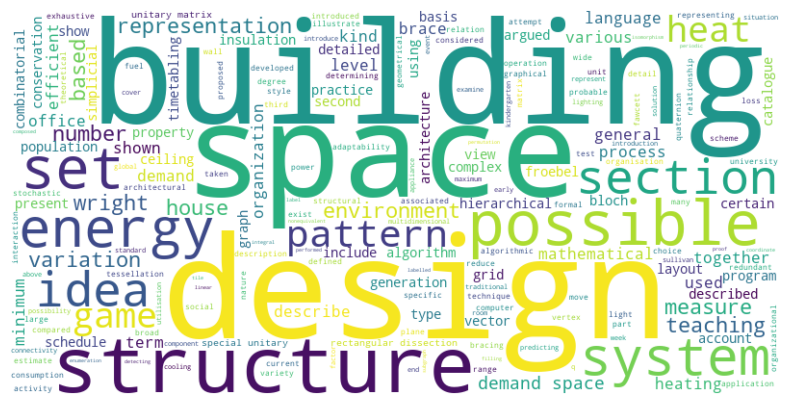

In [162]:
__create_word_cloud__(df70['abstract'], stop_words)

In [150]:
df80['abstract'] = __col_preprocess__(df80['Abstract Note'], stop_words)
df80['title_en'] = __col_preprocess__(df80['Title'], stop_words)
df80.head()

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,System,Code,Code Number,Section,Session,Committee,History,Legislative Body,abstract,title_en
0,N8CNNTHU,journalArticle,1980,"Koleichuk, V F",Programmed Form Generation in Design,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b070019,https://doi.org/10.1068/b070019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,distinguishes design concerned development exi...,programmed form generation design
1,LWBR29RD,journalArticle,1982,"Faludi, A; Mastop, J M",The ‘IOR School’: The Development of a Plannin...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b090241,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ior school represents main stream planningmeth...,‘ior school’ development planning
2,UV73TU43,journalArticle,1982,"Voogd, H",Multicriteria Evaluation with Mixed Qualitativ...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b090221,https://doi.org/10.1068/b090221,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,attention focussed development multicriteria e...,multicriteria evaluation mixed qualitative qua...
3,7BT83LRG,journalArticle,1982,"Sharpe, R; Roy, J R; Taylor, M A P",Optimizing Urban Futures,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b090209,https://doi.org/10.1068/b090209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mental descriptive mathematical modelling proc...,optimizing future
4,H8T7EHTZ,journalArticle,1982,"Nijkamp, P",Soft Multicriteria Analysis as a Tool in Urban...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b090197,https://doi.org/10.1068/b090197,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,deal qualitative multicriteria analysis physic...,soft multicriteria tool landuse planning


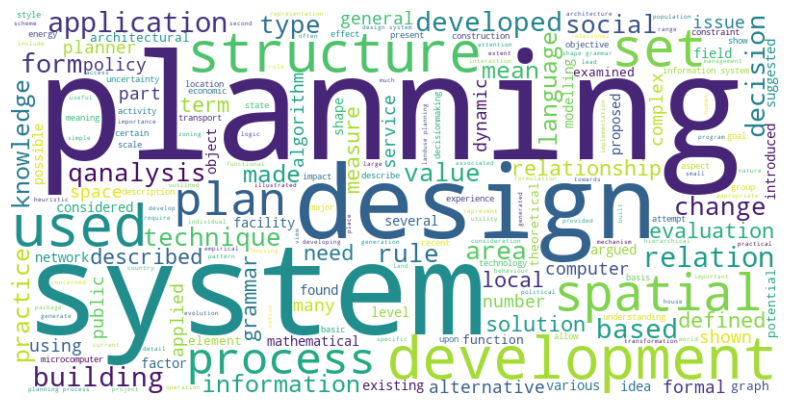

In [151]:
__create_word_cloud__(df80['abstract'], stop_words)

In [152]:
df90.head()

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,Programming Language,Version,System,Code,Code Number,Section,Session,Committee,History,Legislative Body
0,728N98FM,journalArticle,1992,"Brotherton, D I",On the Control of Development by Planning Auth...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190465,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3XNSEKJL,journalArticle,1992,"Krishnamurti, R",The Arithmetic of Maximal Planes,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190431,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4TLARWHG,journalArticle,1992,"Stiny, G",Weights,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190413,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CUGAQQDS,journalArticle,1992,"Hebbert, M",Town Planner as Social Scientist: The Case of ...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190403,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,UQLEKIEK,journalArticle,1992,"Holtier, S",Patterns of Structural-Qualitative Changes in ...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190375,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [153]:
df90['Abstract Note'] = df90['Abstract Note'].astype(str)
df90['Title'] = df90['Title'].astype(str)

df90['abstract'] = __col_preprocess__(df90['Abstract Note'], stop_words)
df90['title_en'] = __col_preprocess__(df90['Title'], stop_words)
df90.head()

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,System,Code,Code Number,Section,Session,Committee,History,Legislative Body,abstract,title_en
0,728N98FM,journalArticle,1992,"Brotherton, D I",On the Control of Development by Planning Auth...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190465,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,degree local planning authority lpas control d...,control development planning authority
1,3XNSEKJL,journalArticle,1992,"Krishnamurti, R",The Arithmetic of Maximal Planes,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190431,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,geometry shape made finite plane considered de...,arithmetic maximal plane
2,4TLARWHG,journalArticle,1992,"Stiny, G",Weights,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190413,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,algebra shape uij augmented label weight form ...,weight
3,CUGAQQDS,journalArticle,1992,"Hebbert, M",Town Planner as Social Scientist: The Case of ...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190403,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,originated international congress planning tea...,town planner social scientist lse programme
4,UQLEKIEK,journalArticle,1992,"Holtier, S",Patterns of Structural-Qualitative Changes in ...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b190375,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,attempt outline emancipatory fashion thinking ...,pattern structuralqualitative change developme...


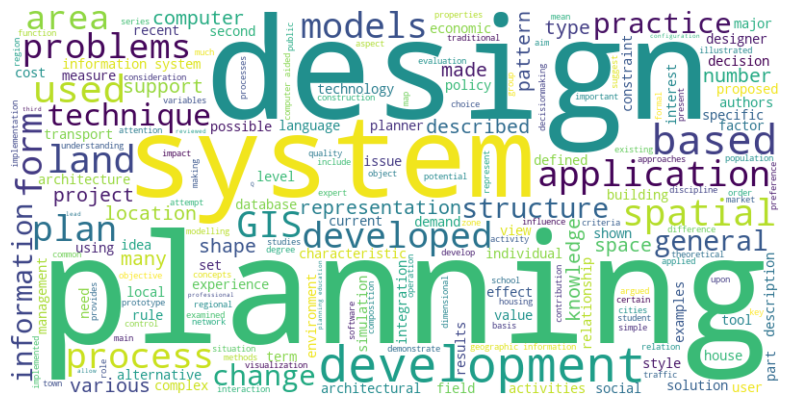

In [155]:
__create_word_cloud__(df90['Abstract Note'], stop_words)

In [135]:
df00['Abstract Note'] = df00['Abstract Note'].astype(str)
df00['Title'] = df00['Title'].astype(str)
df00['abstract'] = __col_preprocess__(df00['Abstract Note'],stop_words)
df00['title_en'] = __col_preprocess__(df00['Title'], stop_words)
df00.head()

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,System,Code,Code Number,Section,Session,Committee,History,Legislative Body,abstract,title_en
0,8EI3GWEK,journalArticle,2009,"Mohamed, Rayman",Why Do Residential Developers Prefer Large Exu...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b33120,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,completely understood onsite cost infrastructu...,residential developer prefer large exurban lot...
1,QMRU4Z69,journalArticle,2009,"Bramley, Glen; Power, Sinéad",Urban Form and Social Sustainability: The Role...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b33129,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,united kingdom planning favour compact highden...,form social sustainability role density housin...
2,58LP28D9,journalArticle,2009,"Kok, Kasper; van Delden, Hedwig",Combining Two Approaches of Integrated Scenari...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b32137,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,desertification spain societydriven process ma...,combining approach integrated scenario develop...
3,PI572MDX,journalArticle,2009,"Kang, Hejun; Scott, Darren M; Kanaroglou, Pavl...",An Exploration of Issues Related to the Study ...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b33070,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,generated traffic received considerable worldw...,exploration issue generated traffic impact ari...
4,RXK7282P,journalArticle,2009,"Lee, Jiyeong",GIS-Based Geocoding Methods for Area-Based Add...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b31169,https://journals.sagepub.com/doi/abs/10.1068/b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,decade addressmatching method streetbased addr...,gisbased geocoding method areabased address 3d...


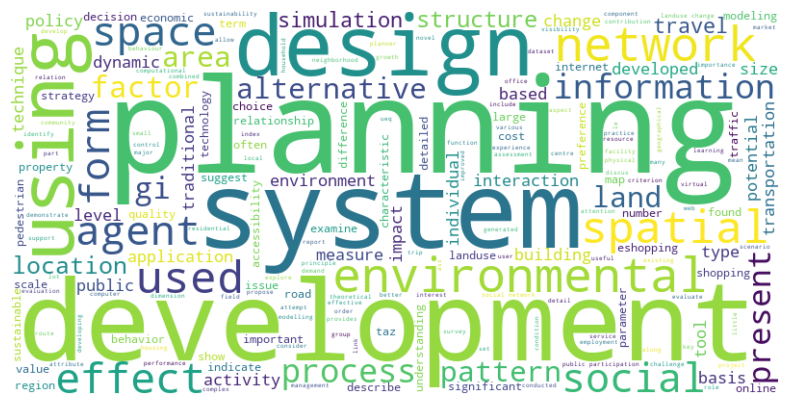

In [136]:
__create_word_cloud__(df00['abstract'], stop_words)

In [137]:
df10['Abstract Note'] = df10['Abstract Note'].astype(str)
df10['Title'] = df10['Title'].astype(str)
df10['abstract'] = __col_preprocess__(df10['Abstract Note'], stop_words)
df10['title_en'] = __col_preprocess__(df10['Title'], stop_words)
df10.head()

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,System,Code,Code Number,Section,Session,Committee,History,Legislative Body,abstract,title_en
0,UB8SD7KP,journalArticle,2015,"Scoppa, Martin D; Peponis, John",Distributed Attraction: The Effects of Street ...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b130051p,https://doi.org/10.1068/b130051p,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,buenos aire radial street plan regular block c...,distributed attraction effect street network c...
1,Z8JGJVH4,journalArticle,2015,"Morrissey, Karyn; Clarke, Graham; Williamson, ...",Mental Illness in Ireland: Simulating its Geog...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b130054p,https://doi.org/10.1068/b130054p,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,traditionally ireland reported high rate admis...,mental illness ireland simulating geographical...
2,U6C87W4D,journalArticle,2015,"Hu, Hong; Geertman, Stan; Hooimeijer, Pieter",Planning Support in Estimating Green Housing O...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b130192p,https://doi.org/10.1068/b130192p,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sustainable often criticized unaffordable majo...,planning support estimating green housing oppo...
3,HDZE749E,journalArticle,2015,"Schmitt, Clara; Rey-Coyrehourcq, Sébastien; Re...",Half a Billion Simulations: Evolutionary Algor...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b130064p,https://doi.org/10.1068/b130064p,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,multiagent geographical model integrate large ...,half billion simulation evolutionary algorithm...
4,CXKH9SSM,journalArticle,2015,"Chen, S S; Yan, Yue; Gao, Qun; Liu, Dene",Quantifying Circular Urban Expansion Patterns ...,Environment and Planning B: Planning and Design,NaN,0265-8135,10.1068/b120004p,https://doi.org/10.1068/b120004p,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,accelerating urbanization world renewed interd...,quantifying circular expansion pattern compact...


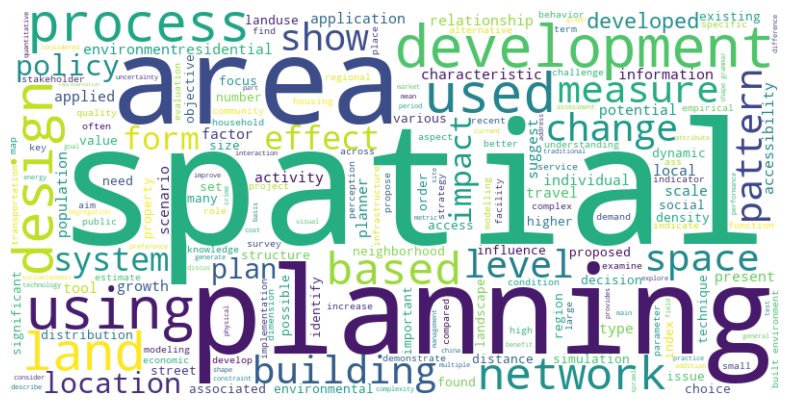

In [138]:
__create_word_cloud__(df10['abstract'], stop_words)

In [139]:
df20['Abstract Note'] = df20['Abstract Note'].astype(str)
df20['Title'] = df20['Title'].astype(str)
df20['abstract'] = __col_preprocess__(df20['Abstract Note'], stop_words)
df20['title_en'] = __col_preprocess__(df20['Title'], stop_words)
df20.head()

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,System,Code,Code Number,Section,Session,Committee,History,Legislative Body,abstract,title_en
0,SDGV2F6Y,journalArticle,2020,"Huang, Bo; Zhou, Yulun; Li, Zhigang; Song, Yim...",Evaluating and characterizing urban vibrancy u...,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319828730,https://doi.org/10.1177/2399808319828730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,recognize vibrancy sense developing direct com...,evaluating characterizing vibrancy using spati...
1,4QSHS7BK,journalArticle,2020,"Lopez, Juan Carlos G; Arnott, Richard J",Is higher-quality land developed earlier?,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319828728,https://doi.org/10.1177/2399808319828728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,higherquality land developed earlier answer ap...,higherquality land developed earlier
2,UENTSCDV,journalArticle,2020,"Humphrey, Colman; Jensen, Shane T; Small, Dyla...",Urban vibrancy and safety in Philadelphia,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319830403,https://doi.org/10.1177/2399808319830403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,analysis environment recently improved publicl...,vibrancy safety philadelphia
3,W8KSI8JB,journalArticle,2020,"Wilson, Alexander; Tewdwr-Jones, Mark",Let’s draw and talk about urban change: Deploy...,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319831290,https://doi.org/10.1177/2399808319831290,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,enhancing role citizen shaping place longstand...,let’s draw talk change deploying digital techn...
4,I2D4CUJX,journalArticle,2020,"Lu, Yi; Laffan, Shawn; Pettit, Chris; Cao, Min",Land use change simulation and analysis using ...,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319830971,https://doi.org/10.1177/2399808319830971,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,loss accuracy vectorraster conversion always i...,land change simulation using vector cellular a...


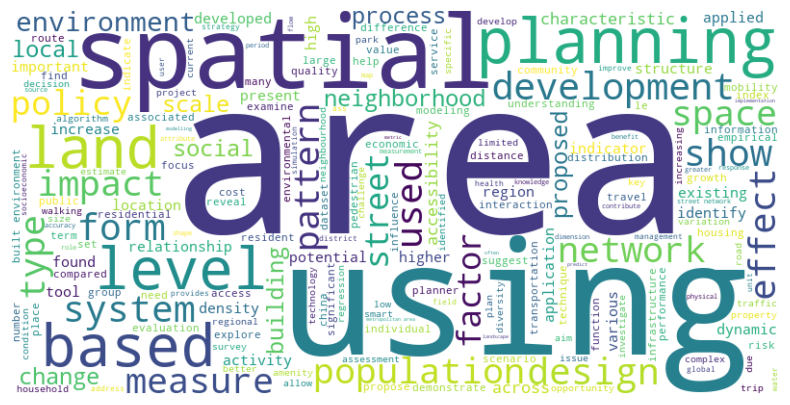

In [140]:
__create_word_cloud__(df20['abstract'], stop_words)